# Water Use Models 🌆🌳
Non Land Water Use Database provided by CR2 on 24 April 2023
Demographic Information Instituto Nacional de Estadística

Mariana Bruning-González mariana.bruning@alumnos.uach.cl Doctorado en Ecología y Evolución, Universidad Austral de Chile

# Packages

In [1]:
import pandas as pd
import plotly.graph_objects as go
import geopandas as gpd 
import matplotlib.pyplot as plt
import plotly.express as px 
import plotly.graph_objs as pg
import datetime
import numpy as np
import scipy.interpolate
import statsmodels
#import requests
import geojson
from geojson import GeometryCollection, Point, LineString, Feature, FeatureCollection
import ast
import statsmodels.api as sm
import os
#import networkx as nx
from plotly.subplots import make_subplots
import plotly.graph_objects as go
#from sklearn.preprocessing import StandardScaler
#from sklearn.decomposition import PCA
#from sklearn.cluster import KMeans
#from sklearn.metrics import pairwise_distances_argmin_min
from scipy.stats import boxcox, yeojohnson
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
#from sklearn.linear_model import LinearRegression
from scipy.stats import shapiro
#import seaborn as sns
import statsmodels.formula.api as smf

# Ingreso a carpetas, lectura y limpieza de datos / Entry folders, data lecture and cleaning

## Directorio / Directory

In [2]:
# Establecer ruta / Set path
path = r'/Users/marianabruninggonzalez/Desktop/Modelostesisjulio2025/Water_use_py/Python'

# Cambia el directorio actual / Update current path
os.chdir(path)


## Lectura de datos / Data lecture

In [3]:
# Modelo 1 escalamiento poblacional 
df_model1 = pd.read_csv('df_model1.csv')

In [4]:
# Modelo 2  regresión múltiple 
df_model2wu = pd.read_csv('df_model2_wu_r.csv')
df_model2 = pd.read_csv('df_model2_r.csv')

In [ ]:
print(df_model1.DrinkingWater.mean())
print(df_model1.DrinkingWater.std())
print(df_model1.DrinkingWater_urb.mean())
print(df_model1.DrinkingWater_urb.std())
print(df_model1.Industrial.mean())
print(df_model1.Industrial.std())


0.1458452756636489
0.2555856972751879
0.13433203337425195
0.2564340492377618
1.0254663440294804
1.5430283067664976
50498.48826147
78152.67494336326
44201.92235691269
78077.81743070949
6296.565904557312
6190.6693003975915


In [13]:
print(df_model1.Population.mean())
print(df_model1.Population.std())
print(df_model1.Pop_urb.mean())
print(df_model1.Pop_urb.std())
print(df_model1.Pop_rur.mean())
print(df_model1.Pop_rur.std())

50498.48826147
78152.67494336326
44201.92235691269
78077.81743070949
6296.565904557312
6190.6693003975915


In [22]:
df_model1[df_model1['Years']==2017]

,Unnamed: 0,Years,cod_reg,nom_reg,cod_com,nom_com,lat,long,Population,Pop_urb,Pop_rur,DrinkingWater_urb,DrinkingWater,Energy,Industry,Livestock,Mining,Irrigated,NLWU,Industrial
5145,5145,2017,1,REGIÓN DE TARAPACÁ,1101,IQUIQUE,-20.925600,-70.048159,202891.0,199530.0,3361.0,0.696301,0.699701,0.5093,0.000,0.000004,0.460527,0.000122,1.669532,0.969953
5146,5146,2017,1,REGIÓN DE TARAPACÁ,1107,ALTO HOSPICIO,-20.189737,-70.012645,113098.0,110813.0,2285.0,0.247876,0.251376,0.0000,0.000,0.000267,0.000000,0.000000,0.251643,0.000267
5147,5147,2017,1,REGIÓN DE TARAPACÁ,1401,POZO ALMONTE,-20.772130,-69.507973,15286.0,9952.0,5334.0,0.030335,0.038135,0.0000,0.000,0.000408,0.581593,0.013817,0.620136,0.595818
5148,5148,2017,1,REGIÓN DE TARAPACÁ,1402,CAMIÑA,-19.369994,-69.501124,1286.0,0.0,1286.0,0.000000,0.001700,0.0000,0.000,0.000414,0.000000,0.081437,0.002114,0.081851
5149,5149,2017,1,REGIÓN DE TARAPACÁ,1403,COLCHANE,-19.354497,-68.844999,1500.0,0.0,1500.0,0.000000,0.002400,0.0000,0.000,0.000986,0.000000,0.078936,0.003386,0.079922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5483,5483,2017,16,REGIÓN DE ÑUBLE,16301,SAN CARLOS,-36.385763,-72.018401,55278.0,35217.0,20061.0,0.086593,0.122193,0.0000,0.022,0.024590,0.000000,4.485878,0.168783,4.532468
5484,5484,2017,16,REGIÓN DE ÑUBLE,16302,COIHUECO,-36.701966,-71.581425,27680.0,9612.0,18068.0,0.021738,0.053938,0.0000,0.000,0.010209,0.000000,3.450225,0.064147,3.460434
5485,5485,2017,16,REGIÓN DE ÑUBLE,16303,ÑIQUÉN,-36.301886,-71.898165,11532.0,1218.0,10314.0,0.002600,0.020600,0.0000,0.000,0.006377,0.000000,2.441391,0.026977,2.447768
5486,5486,2017,16,REGIÓN DE ÑUBLE,16304,SAN FABIÁN,-36.579944,-71.287422,4513.0,1667.0,2846.0,0.003800,0.008500,0.0000,0.000,0.001971,0.000000,0.085529,0.010471,0.087500


In [24]:

print(df_model1[df_model1['Years']==2017]['Industrial'].describe())
print(df_model2['Industrial'].describe())

count    343.000000
mean       1.000385
std        1.523407
min        0.000000
25%        0.039702
50%        0.267500
75%        1.445873
max       13.409922
Name: Industrial, dtype: float64
count    323.000000
mean       0.261451
std        1.020098
min        0.000000
25%        0.001944
50%        0.012028
75%        0.074837
max       13.409922
Name: Industrial, dtype: float64


In [ ]:
# al parecer Industrial de df_model1 lo hice sumando irrigated.. así que voy a comprobar
df_model1['Industrial_']= df_model1['Industry'] + df_model1['Mining'] + df_model1['Livestock'] + df_model1['Energy']
print('M1 bbdd todos los años',df_model1.shape)
print('M1 Industrial con riego',df_model1[df_model1['Years']==2017]['Industrial'].describe())
print('M1 Industrial sin riego',df_model1[df_model1['Years']==2017]['Industrial_'].describe())
print('M2 bbdd solo 2017',df_model2.shape)
print('M2 Industrial sin riego',df_model2['Industrial'].describe()) #esta bbdd tiene 20 comunas menos porque no tenían dato del ISMT

# dfmodel2 está sin riego (está bien)

M1 bbdd todos los años (6517, 21)
M1 Industrial con riego count    343.000000
mean       1.000385
std        1.523407
min        0.000000
25%        0.039702
50%        0.267500
75%        1.445873
max       13.409922
Name: Industrial, dtype: float64
M1 Industrial sin riego count    343.000000
mean       0.247569
std        0.991532
min        0.000000
25%        0.001944
50%        0.011230
75%        0.067334
max       13.409922
Name: Industrial_, dtype: float64
M2 bbdd solo 2017 (323, 28)
M2 Industrial sin riego count    323.000000
mean       0.261451
std        1.020098
min        0.000000
25%        0.001944
50%        0.012028
75%        0.074837
max       13.409922
Name: Industrial, dtype: float64


In [26]:
fig = make_subplots(rows=3, cols=2,subplot_titles=("DrinkingWater", "DrinkingWater_urb", "Population",
                                                   "Pop_urb","Industrial_", "Pop_rur"))

fig.add_trace(go.Histogram(x=df_model1['DrinkingWater'],marker_color='#377EB8'),row=1,col=1)
fig.add_trace(go.Histogram(x=df_model1['DrinkingWater_urb'],marker_color='#377EB8',nbinsx=100),row=1,col=2)
fig.add_trace(go.Histogram(x=df_model1['Population'],marker_color='#C7C7C7',nbinsx=100),row=2,col=1)
fig.add_trace(go.Histogram(x=df_model1['Pop_urb'],marker_color='#7F7F7F'),row=2,col=2)
fig.add_trace(go.Histogram(x=df_model1['Industrial_'],marker_color='#C7C7C7'),row=3,col=1)
fig.add_trace(go.Histogram(x=df_model1['Pop_rur'],marker_color='#C7C7C7'),row=3,col=2)
fig.update_traces(marker=dict(line=dict(color='#000000',width=1)),
                  )
fig.update_layout(showlegend=False,font=dict(size=12, color='black'),
                  template='plotly_white',width=900,height=900)
fig.show()

In [28]:
fig=px.histogram(df_model1, x="Industrial_",
                 color_discrete_sequence=['#377EB8'])
fig.update_traces(marker=dict(line=dict(color='#000000',width=1)),
                  )
fig.update_layout(showlegend=False,font=dict(size=12, color='black'),
                  template='plotly_white',width=900,height=600)
fig.show()

In [27]:
fig.write_image("dist_var_scaling.pdf", format="pdf", width=1800, height=1200)
fig.write_image("dist_var_scaling.svg", format="svg", width=1800, height=1200)
fig.write_image("dist_var_scaling.png", format="png", width=1800, height=1200)

In [13]:
# Maps and names

comunas = gpd.read_file("communes_ContinentalChile_epsg4326.geojson")
comunas.rename(columns={'id':'cod_com'}, inplace=True)
com_reg = pd.read_csv('LUT_cod_com_Chile.csv')

print(comunas.head())
print(com_reg.head())

comunas['cod_com'] = comunas['cod_com'].astype(str)
com_reg['cod_com'] = com_reg['cod_com'].astype(str)

comunas = comunas.merge(com_reg[['cod_com', 'nom_com', 'nom_reg']], on='cod_com', how='left')
comunas.head()

  cod_com                                           geometry
0   12102  MULTIPOLYGON (((-70.87538 -52.05205, -70.8714 ...
1    2202  MULTIPOLYGON (((-68.41255 -20.9346, -68.295 -2...
2   12303  MULTIPOLYGON (((-69.59061 -53.63301, -69.58709...
3   11303  MULTIPOLYGON (((-74.00951 -46.97023, -74.01273...
4   12103  MULTIPOLYGON (((-71.47365 -52.65077, -71.46971...
   cod_com        nom_com  cod_pro    nom_pro  cod_reg             nom_reg
0     1101        IQUIQUE       11    IQUIQUE        1  REGIÓN DE TARAPACÁ
1     1107  ALTO HOSPICIO       11    IQUIQUE        1  REGIÓN DE TARAPACÁ
2     1401   POZO ALMONTE       14  TAMARUGAL        1  REGIÓN DE TARAPACÁ
3     1402         CAMIÑA       14  TAMARUGAL        1  REGIÓN DE TARAPACÁ
4     1403       COLCHANE       14  TAMARUGAL        1  REGIÓN DE TARAPACÁ


,cod_com,geometry,nom_com,nom_reg
0,12102,"MULTIPOLYGON (((-70.87538 -52.05205, -70.8714 ...",LAGUNA BLANCA,REGIÓN DE MAGALLANES Y DE LA ANTÁRTICA CHILENA
1,2202,"MULTIPOLYGON (((-68.41255 -20.9346, -68.295 -2...",OLLAGÜE,REGIÓN DE ANTOFAGASTA
2,12303,"MULTIPOLYGON (((-69.59061 -53.63301, -69.58709...",TIMAUKEL,REGIÓN DE MAGALLANES Y DE LA ANTÁRTICA CHILENA
3,11303,"MULTIPOLYGON (((-74.00951 -46.97023, -74.01273...",TORTEL,REGIÓN DE AYSÉN DEL GENERAL CARLOS IBÁÑEZ DEL ...
4,12103,"MULTIPOLYGON (((-71.47365 -52.65077, -71.46971...",RÍO VERDE,REGIÓN DE MAGALLANES Y DE LA ANTÁRTICA CHILENA


In [14]:
areas_pob = gpd.read_file("Areas_Pobladas/Areas_Pobladas.shp") #otro shape descargado de BCN para visualizar comunas muy grandes (cordilleranas)

areas_pob['comuna'] = areas_pob['comuna'].str.upper()

areas_pob.rename(columns={'comuna':'nom_com'}, inplace=True)

areas_pob = areas_pob.to_crs(comunas.crs)

/Users/marianabruninggonzalez/Library/Python/3.9/lib/python/site-packages/pyogrio/raw.py:198: RuntimeWarning:

organizePolygons() received an unexpected geometry.  Either a polygon with interior rings, or a polygon with less than 4 points, or a non-Polygon geometry.  Return arguments as a collection.

/Users/marianabruninggonzalez/Library/Python/3.9/lib/python/site-packages/pyogrio/raw.py:198: RuntimeWarning:

Geometry of polygon of fid 421 cannot be translated to Simple Geometry. All polygons will be contained in a multipolygon.



# Dictionaries

In [15]:
STGO = [
    # Provincia Cordillera + Pop
    'PUENTE ALTO', 'SAN BERNARDO',
    # Provincia Santiago
    'CERRILLOS', 'CERRO NAVIA', 'CONCHALÍ', 'EL BOSQUE', 
    'ESTACIÓN CENTRAL', 'HUECHURABA', 'INDEPENDENCIA', 
    'LA CISTERNA', 'LA FLORIDA', 'LA GRANJA', 'LA PINTANA', 
    'LA REINA', 'LAS CONDES', 'LO ESPEJO', 
    'LO PRADO', 'MACUL', 'ÑUÑOA', 
    'PEDRO AGUIRRE CERDA', 'PEÑALOLÉN', 'PROVIDENCIA', 
    'QUILICURA', 'QUINTA NORMAL', 'RECOLETA', 
    'RENCA', 'SAN JOAQUÍN', 'SAN MIGUEL', 'SAN RAMÓN', 
    'SANTIAGO', 'VITACURA',
    'PUDAHUEL','MAIPÚ','LO BARNECHEA',
]

In [16]:
CONCE = [
    'CONCEPCIÓN', 'CHIGUAYANTE', 'HUALPÉN', 
    'PENCO', 'SAN PEDRO DE LA PAZ', 'TALCAHUANO',
    'TOMÉ', 'CORONEL', 'HUALQUI', 'SANTA JUANA', 'LOTA'
]

In [17]:
VALPO = [
    'VIÑA DEL MAR', 'VALPARAÍSO', 'QUILPUÉ',
    'VILLA ALEMANA', 'CONCÓN'
]
# ÁREA METROPOLITANA GRAN VALPARAÍSO

# Modelo escalamiento poblacional / Population scaling model

### Population vs DW, Industrial, NLWU

In [ ]:
# 1 hacer el dataframe con log

df_model1log = df_model1.copy()  
df_model1log['Log_Pop'] = np.log(df_model1log['Population'])
df_model1log['Log_DW'] = np.log(df_model1log['DrinkingWater'])

In [ ]:
# 2 verificar valores negativos industrial
print(df_model1log[["Industrial"]].isin([0]).sum())                   # cuántas comunas tienen valor 0 en Industrial (este incluía Irrigated)
print(df_model1log[["Industrial_"]].isin([0]).sum())                         # cuántas comunas tienen valor 0 en Industrial
print(df_model1log[df_model1log['Industrial']==0]['nom_com'].unique() )      # cuáles comunas (incluye uso agrígocola)
print(df_model1log[df_model1log['Industrial_']==0]['nom_com'].unique())      # cuáles comunas 

        # los datos socioeconómicos que tengo no explicarían el uso industrial (comunas uso industrial muy bajo pero datos socioeconómicos altos)
        # para no eliminar estas comunas del análisis, aplicaré otra transformación logarítmica

In [ ]:
# 3 verificar valores negativos poblaciones
print('VALORES NEGATIVOS Pob urb')
print(df_model1log[["Pop_urb"]].isin([0]).sum())                   # cuántas comunas tienen valor 0 
print(df_model1log[df_model1log['Pop_urb']==0]['nom_com'].unique() )      # cuáles comunas 
print('VALORES NEGATIVOS Pob rur')
print(df_model1log[["Pop_rur"]].isin([0]).sum())                         # cuántas comunas tienen valor 0 
print(df_model1log[df_model1log['Pop_rur']==0]['nom_com'].unique())      # cuáles comunas 
# son caleta, así que log1p

VALORES NEGATIVOS Pob urb
Pop_urb    535
dtype: int64
['CAMIÑA' 'COLCHANE' 'HUARA' 'SIERRA GORDA' 'OLLAGÜE' 'ALTO DEL CARMEN'
 'PAIGUANO' 'RÍO HURTADO' 'NAVIDAD' 'PUMANQUE' 'VICHUQUÉN' 'COCHAMÓ'
 'CURACO DE VÉLEZ' 'PUQUELDÓN' 'SAN JUAN DE LA COSTA' 'PALENA'
 'LAGO VERDE' "O'HIGGINS" 'TORTEL' 'RÍO IBÁÑEZ' 'LAGUNA BLANCA'
 'RÍO VERDE' 'SAN GREGORIO' 'PRIMAVERA' 'TIMAUKEL' 'TORRES DEL PAINE'
 'SAN PEDRO' 'CAMARONES' 'GENERAL LAGOS' 'ALTO BIOBÍO']
VALORES NEGATIVOS Pob rur
Pop_rur    528
dtype: int64
['VIÑA DEL MAR' 'SANTIAGO' 'CERRILLOS' 'CERRO NAVIA' 'CONCHALÍ'
 'EL BOSQUE' 'ESTACIÓN CENTRAL' 'HUECHURABA' 'INDEPENDENCIA' 'LA CISTERNA'
 'LA GRANJA' 'LA PINTANA' 'LA REINA' 'LAS CONDES' 'LO ESPEJO' 'LO PRADO'
 'MACUL' 'ÑUÑOA' 'PEDRO AGUIRRE CERDA' 'PEÑALOLÉN' 'PROVIDENCIA'
 'QUINTA NORMAL' 'RECOLETA' 'RENCA' 'SAN JOAQUÍN' 'SAN MIGUEL' 'SAN RAMÓN'
 'VITACURA']


In [ ]:
# 4 verificar valores negativos DW urbano e irrigated
print('VALORES NEGATIVOS DW urb')
print(df_model1log[["DrinkingWater_urb"]].isin([0]).sum())                         # cuántas comunas tienen valor 0 
print(df_model1log[df_model1log['DrinkingWater_urb']==0]['nom_com'].unique())      # cuáles comunas 
print('VALORES NEGATIVOS Irrigated')
print(df_model1log[["Irrigated"]].isin([0]).sum())                         # cuántas comunas tienen valor 0 
print(df_model1log[df_model1log['Irrigated']==0]['nom_com'].unique())      # cuáles comunas 
# son caleta, así que log1p

VALORES NEGATIVOS DW urb
DrinkingWater_urb    386
dtype: int64
['CAMIÑA' 'COLCHANE' 'OLLAGÜE' 'ALTO DEL CARMEN' 'RÍO HURTADO' 'PUMANQUE'
 'COCHAMÓ' 'CURACO DE VÉLEZ' 'PUQUELDÓN' 'PALENA' 'LAGO VERDE' "O'HIGGINS"
 'TORTEL' 'LAGUNA BLANCA' 'RÍO VERDE' 'SAN GREGORIO' 'PRIMAVERA'
 'TIMAUKEL' 'TORRES DEL PAINE' 'SAN PEDRO' 'CAMARONES' 'GENERAL LAGOS'
 'ALTO BIOBÍO']
VALORES NEGATIVOS Irrigated
Irrigated    437
dtype: int64
['IQUIQUE' 'ALTO HOSPICIO' 'COLCHANE' 'ANTOFAGASTA' 'MEJILLONES'
 'SIERRA GORDA' 'TALTAL' 'OLLAGÜE' 'TOCOPILLA' 'CHAÑARAL'
 'DIEGO DE ALMAGRO' 'GUAITECAS' 'COCHRANE' "O'HIGGINS" 'TORTEL'
 'PUNTA ARENAS' 'LAGUNA BLANCA' 'RÍO VERDE' 'SAN GREGORIO'
 'CABO DE HORNOS' 'PORVENIR' 'PRIMAVERA' 'TIMAUKEL' 'TORRES DEL PAINE'
 'SANTIAGO' 'SAN MIGUEL' 'GENERAL LAGOS' 'LA REINA' 'ÑUÑOA']


In [19]:
# hacer los log de las variables con ceros
df_model1log = df_model1log.astype({'nom_com': str}) # esto no me acuerdo por qué era, pero lo tenía así

df_model1log['Log_Industrial'] = np.log1p(df_model1log['Industrial']) # Usa log(1 + x) porque tiene ceros
df_model1log['Log_Industrial_'] = np.log1p(df_model1log['Industrial_']) # Usa log(1 + x) porque tiene ceros
df_model1log['Log_Pop_urb'] = np.log1p(df_model1log['Pop_urb']) # Usa log(1 + x) porque tiene ceros
df_model1log['Log_Pop_rur'] = np.log1p(df_model1log['Pop_rur']) # Usa log(1 + x) porque tiene ceros
df_model1log['Log_DW_urb'] = np.log1p(df_model1log['DrinkingWater_urb']) # Usa log(1 + x) porque tiene ceros
df_model1log['Log_Irrigated'] = np.log1p(df_model1log['Irrigated']) # Usa log(1 + x) porque tiene ceros

# Solo año 2020
df_model1log_2020 = df_model1log[df_model1log['Years'] == 2020]
# Solo año 2017
df_model1log_2017 = df_model1log[df_model1log['Years'] == 2017]
# Solo año 2002
df_model1log_2002 = df_model1log[df_model1log['Years'] == 2002]
# Solo año 1992
df_model1log_1992 = df_model1log[df_model1log['Years'] == 1992]



In [ ]:
# ESTO HACERLO PARA AÑOS ESPECÍFICOS PARA NO BORRAR TANTOS DATOS
# Drop Industrial = 0 / Eliminar comunas Industrial = 0
df_model1log_sinInd = df_model1log[df_model1log['Industrial_'] != 0]         # eliminar las comunas sin consumo industrial (energy+mining+livestock+industry)
print(df_model1log_sinInd.shape)                                             # ver cuántas comunas quedan
df_model1log_sinInd['Log_Industrial'] = np.log(df_model1log_sinInd['Industrial_'])           # hacer columna con log industrial (sin ceros)
df_model1log_sinInd = df_model1log_sinInd[df_model1log_sinInd['Log_Industrial'] > -20]       # para no plotear outliers

In [41]:
# los log log exploratorios (Figure 2) tienen que incluir los datos socioeconómicos de df_model2, así que usaré df_model1log_2017 y df_model2 para hacer los gráficos

print(df_model1log_2017.columns,df_model1log_2017.shape)
print(df_model2.columns,df_model2.shape)

df_model2 = df_model2.astype({'nom_com': str}) # esto no me acuerdo por qué era, pero lo tenía así

df_model2['Log_DW'] = np.log(df_model2['DrinkingWater'])
df_model2["Log_Industrial"] = np.log1p(df_model2["Industrial"]) # Usa log(1 + x) porque tiene ceros
df_model2_0 = df_model2[df_model2['Industrial'] != 0] # dataframe sin comunas = 0
df_model2_0["log_Industrial"] = np.log(df_model2_0["Industrial"]) # re escribir log_Industrial en dataframe filtrado sin 0

df_model2["Log_Pop"] = np.log(df_model2["Population"])
df_model2["Log_Firms"] = np.log(df_model2["Firms"])
df_model2["Log_Rev_firm"] = np.log(df_model2["Revenue_per_firm"])
df_model2['Log_precip'] = np.log(df_model2['Precipitation'])
df_model2['Log_ismt'] = np.log(df_model2['ISMT'])
df_model2['Log_temp'] = np.log(df_model2['Temperature'])
df_model2["Log_Density"] = np.log(df_model2["Density"])
df_model2["Log_Revenue"] = np.log(df_model2["Revenue"])
df_model2["Log_Employees"] = np.log(df_model2["Employees"])
df_model2["Log_Workers"] = np.log(df_model2["Workers"])
df_model2["Log_Latitude"] = np.log(df_model2["Latitude"].abs())

Index(['Unnamed: 0', 'Years', 'cod_reg', 'nom_reg', 'cod_com', 'nom_com',
       'lat', 'long', 'Population', 'Pop_urb', 'Pop_rur', 'DrinkingWater_urb',
       'DrinkingWater', 'Energy', 'Industry', 'Livestock', 'Mining',
       'Irrigated', 'NLWU', 'Industrial', 'Industrial_', 'Log_Pop',
       'Log_Pop_urb', 'Log_Pop_rur', 'Log_DW', 'Log_DW_urb', 'Log_Industrial',
       'Log_Industrial_', 'Log_Irrigated'],
      dtype='object') (343, 29)
Index(['Unnamed: 0', 'Years', 'cod_com', 'nom_com', 'cod_reg', 'nom_reg',
       'DrinkingWater', 'Energy', 'Industry', 'Livestock', 'Mining',
       'Population', 'Macrozona', 'ISMT', 'T_POB_R', 'T_POB_U', 'SUPERFICIE',
       'Density', 'Firms', 'Revenue', 'Employees', 'Workers', 'Precipitation',
       'Temperature', 'Latitude', 'Industrial', 'NLWU', 'Revenue_per_firm',
       'log_Firms', 'log_Rev_firm', 'log_precip', 'log_ismt', 'log_temp',
       'log_Density', 'log_Revenue', 'log_Employees', 'log_Workers',
       'log_Latitude', 'log_Pop', 'L

/var/folders/dp/hq1q_fc122s8pmzf1bjlmq000000gn/T/ipykernel_1186/3764871200.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [44]:
# como dfmodel2 no tiene irrigated, se lo voy a agregar desde dfmodel1log_2017
df_model2 = df_model2.merge(df_model1log_2017[['nom_com', 'Irrigated', 'Log_Irrigated']], on='nom_com', how='left')

In [ ]:
# pero df_model1log_2017 tiene 20 comunas más que df_model2 (porque df_model2 no tiene comunas sin dato de ISMT)
# así que solo voy a plotear dfmodel2 para la figura, pero voy a ver cómo se ve DWurb

# NO SÉ POR QUÉ PASA ESTOOOO PERO NO TENGO TIEMPO PARA INVESTIGARLO AHORA

# 2017
fig1= px.scatter(df_model1log_2017,x='Log_Pop_urb',y='Log_DW_urb',trendline='ols',hover_data='nom_com')

fig_final = go.Figure()
# Añadir solo los puntos del primer gráfico (negros)
fig_final.add_trace(
    go.Scatter(
        x=fig1.data[0].x,
        y=fig1.data[0].y,
        mode='markers',
        marker=dict(color='black',size=9,opacity=0.5),
        hoverinfo='text',
        hovertext=df_model1log_2017['nom_com'],  # Asegúrate de que esto funcione con tus datos
    )
)

# fig_final.add_trace(go.Scatter(x=fig1.data[1].x, y=fig1.data[1].y, 
#                                line=dict(color='#56B4E9', width=2), name=''))

fig_final.update_layout(font=dict(size=19, color='black'),showlegend=False,template='plotly_white',xaxis=dict(title=dict(text='Population')),yaxis=dict(title=dict(text='DW')))

fig_final.show()

results = px.get_trendline_results(fig1)
print('n,m trendline',results.iloc[0]['px_fit_results'].params)
#print(results.iloc[0]['px_fit_results'].summary())
print("\nR-cuadrado:", results.iloc[0]['px_fit_results'].rsquared)
print("\beta:",results.iloc[0]['px_fit_results'].params[1])

n,m trendline [-0.2068153   0.03582149]

R-cuadrado: 0.29741833265104234
eta: 0.03582148660217331


In [59]:
# YA, AHORA SÍ SOLO LOS GRAFICOS LOG LOG EXPLORATORIOS PARA 2017 CON DATOS DE DF_MODEL2

# Variables en el orden solicitado
vars_x = [
    'Log_Pop', 'Log_Density', 'Log_Latitude',
    'Log_temp', 'Log_precip', 'Log_ismt', 'Log_Revenue',
    'Log_Firms', 'Log_Employees', 'Log_Rev_firm',
    'Log_Workers'
]

titles = ["", "Pop", "Density", "Lat",
          "Temp", "Precip", "ISMT", "Revenue",
          "Firms", "Employees", "Revenue/Firm",
          "Workers"]

# DW

# Crear figura 3x4
fig = make_subplots(
    rows=3,
    cols=4,
    subplot_titles=titles
)

# --- Celda (1,1): solo texto DW ---
fig.add_annotation(
    text="DW",
    xref="x1", yref="y1",
    x=0.5, y=0.5,
    showarrow=False,
    font=dict(size=50)
)
# Desactivar ejes de (1,1)
fig.update_xaxes(visible=False, row=1, col=1)
fig.update_yaxes(visible=False, row=1, col=1)

# --- Agregar los 11 subplots con scatter + OLS ---
row, col = 1, 2  # Empezamos en 1,2 porque 1,1 ya está ocupada

for v in vars_x:

    # 1. generar scatter + OLS temporal con px
    fig_temp = px.scatter(
        df_model2,
        x=v,
        y="Log_DW",
        trendline="ols",
        hover_data=["nom_com"]
    )

    # -------- puntos --------
    fig.add_trace(
        go.Scatter(
            x=fig_temp.data[0].x,
            y=fig_temp.data[0].y,
            mode='markers',
            marker=dict(color='black', size=7, opacity=0.5),
            hoverinfo='text',
            hovertext=df_model2['nom_com']
        ),
        row=row, col=col
    )

    # -------- línea OLS (data[1]) --------
    fig.add_trace(
        go.Scatter(
            x=fig_temp.data[1].x,
            y=fig_temp.data[1].y,
            mode='lines',
            line=dict(color='#56B4E9',width=2),
            showlegend=False
        ),
        row=row, col=col
    )
    # Obtener OLS
    results = px.get_trendline_results(fig_temp).iloc[0]["px_fit_results"]
    slope = results.params[1]
    r2 = results.rsquared

    # Calcular número real del eje
    axis_index = (row - 1) * 4 + col   # 1..12

    # Agregar anotación dentro del subplot correcto
    fig.add_annotation(
        x=0.02, y=0.95,
        xref=f"x{axis_index} domain",
        yref=f"y{axis_index} domain",
        text=f"β={slope:.3f}<br>R²={r2:.3f}",
        showarrow=False,
        font=dict(size=16),
        align="left"
    )

    # mover puntero del grid
    col += 1
    if col == 5:
        col = 1
        row += 1

# Layout general
fig.update_layout(
    height=900,
    width=1600,
    template="plotly_white",
    font=dict(size=22, color='black'),
    showlegend=False
)

# Cambiar tamaño del font SOLO de los subtítulos de los subplots
for ann in fig.layout.annotations:
    if ann.text in titles:     # titles es tu lista original con los nombres
        ann.font.size = 26     # ajusta el tamaño que quieras


fig.show()

# Industrial

# Crear figura 3x4
fig2 = make_subplots(
    rows=3,
    cols=4,
    subplot_titles=titles
)

# --- Celda (1,1): solo texto  ---
fig2.add_annotation(
    text="Industrial",
    xref="x1", yref="y1",
    x=0.5, y=0.5,
    showarrow=False,
    font=dict(size=40)
)
# Desactivar ejes de (1,1)
fig2.update_xaxes(visible=False, row=1, col=1)
fig2.update_yaxes(visible=False, row=1, col=1)

# --- Agregar los 11 subplots con scatter + OLS ---
row, col = 1, 2  # Empezamos en 1,2 porque 1,1 ya está ocupada

for v in vars_x:

    # 1. generar scatter + OLS temporal con px
    fig_temp = px.scatter(
        df_model2,
        x=v,
        y="Log_Industrial",
        trendline="ols",
        hover_data=["nom_com"]
    )

    # -------- puntos --------
    fig2.add_trace(
        go.Scatter(
            x=fig_temp.data[0].x,
            y=fig_temp.data[0].y,
            mode='markers',
            marker=dict(color='black', size=7, opacity=0.5),
            hoverinfo='text',
            hovertext=df_model2['nom_com']
        ),
        row=row, col=col
    )

    # -------- línea OLS (data[1]) --------
    fig2.add_trace(
        go.Scatter(
            x=fig_temp.data[1].x,
            y=fig_temp.data[1].y,
            mode='lines',
            line=dict(color='#56B4E9',width=2),
            showlegend=False
        ),
        row=row, col=col
    )

    # Obtener OLS
    results = px.get_trendline_results(fig_temp).iloc[0]["px_fit_results"]
    slope = results.params[1]
    r2 = results.rsquared

    # Calcular número real del eje
    axis_index = (row - 1) * 4 + col   # 1..12

    # Agregar anotación dentro del subplot correcto
    fig2.add_annotation(
        x=0.02, y=0.95,
        xref=f"x{axis_index} domain",
        yref=f"y{axis_index} domain",
        text=f"β={slope:.3f}<br>R²={r2:.3f}",
        showarrow=False,
        font=dict(size=16),
        align="left"
    )

    # mover puntero del grid
    col += 1
    if col == 5:
        col = 1
        row += 1

# Layout general
fig2.update_layout(
    height=900,
    width=1600,
    template="plotly_white",
    font=dict(size=22, color='black'),
    showlegend=False
)

# Cambiar tamaño del font SOLO de los subtítulos de los subplots
for ann in fig2.layout.annotations:
    if ann.text in titles:     # titles es tu lista original con los nombres
        ann.font.size = 26     # ajusta el tamaño que quieras


fig2.show()


# Industrial sin ceros

# Crear figura 3x4
fig22 = make_subplots(
    rows=3,
    cols=4,
    subplot_titles=titles
)

# --- Celda (1,1): solo texto  ---
fig22.add_annotation(
    text="Industrial*",
    xref="x1", yref="y1",
    x=0.5, y=0.5,
    showarrow=False,
    font=dict(size=40)
)
# Desactivar ejes de (1,1)
fig22.update_xaxes(visible=False, row=1, col=1)
fig22.update_yaxes(visible=False, row=1, col=1)

# --- Agregar los 11 subplots con scatter + OLS ---
row, col = 1, 2  # Empezamos en 1,2 porque 1,1 ya está ocupada

for v in vars_x:

    # 1. generar scatter + OLS temporal con px
    fig_temp = px.scatter(
        df_model2_0, # usar df_model2 sin comunas con Industrial = 0
        x=v,
        y="Log_Industrial",
        trendline="ols",
        hover_data=["nom_com"]
    )

    # -------- puntos --------
    fig22.add_trace(
        go.Scatter(
            x=fig_temp.data[0].x,
            y=fig_temp.data[0].y,
            mode='markers',
            marker=dict(color='black', size=7, opacity=0.5),
            hoverinfo='text',
            hovertext=df_model2['nom_com']
        ),
        row=row, col=col
    )

    # -------- línea OLS (data[1]) --------
    fig22.add_trace(
        go.Scatter(
            x=fig_temp.data[1].x,
            y=fig_temp.data[1].y,
            mode='lines',
            line=dict(color='#56B4E9',width=2),
            showlegend=False
        ),
        row=row, col=col
    )

    # Obtener OLS
    results = px.get_trendline_results(fig_temp).iloc[0]["px_fit_results"]
    slope = results.params[1]
    r2 = results.rsquared

    # Calcular número real del eje
    axis_index = (row - 1) * 4 + col   # 1..12

    # Agregar anotación dentro del subplot correcto
    fig22.add_annotation(
        x=0.02, y=0.95,
        xref=f"x{axis_index} domain",
        yref=f"y{axis_index} domain",
        text=f"β={slope:.3f}<br>R²={r2:.3f}",
        showarrow=False,
        font=dict(size=16),
        align="left"
    )

    # mover puntero del grid
    col += 1
    if col == 5:
        col = 1
        row += 1

# Layout general
fig22.update_layout(
    height=900,
    width=1600,
    template="plotly_white",
    font=dict(size=22, color='black'),
    showlegend=False
)

# Cambiar tamaño del font SOLO de los subtítulos de los subplots
for ann in fig22.layout.annotations:
    if ann.text in titles:     # titles es tu lista original con los nombres
        ann.font.size = 26     # ajusta el tamaño que quieras



fig22.show()


# Irrigated

# Crear figura 3x4
fig3 = make_subplots(
    rows=3,
    cols=4,
    subplot_titles=titles
)

# --- Celda (1,1): solo texto  ---
fig3.add_annotation(
    text="Irrigated",
    xref="x1", yref="y1",
    x=0.5, y=0.5,
    showarrow=False,
    font=dict(size=40)
)
# Desactivar ejes de (1,1)
fig3.update_xaxes(visible=False, row=1, col=1)
fig3.update_yaxes(visible=False, row=1, col=1)

# --- Agregar los 11 subplots con scatter + OLS ---
row, col = 1, 2  # Empezamos en 1,2 porque 1,1 ya está ocupada

for v in vars_x:

    # 1. generar scatter + OLS temporal con px
    fig_temp = px.scatter(
        df_model2,      # lo tuve que hacer con df_model1log_2017 porque df_model2 no tiene irrigated
        x=v,
        y="Log_Irrigated",
        trendline="ols",
        hover_data=["nom_com"]
    )

    # -------- puntos --------
    fig3.add_trace(
        go.Scatter(
            x=fig_temp.data[0].x,
            y=fig_temp.data[0].y,
            mode='markers',
            marker=dict(color='black', size=7, opacity=0.5),
            hoverinfo='text',
            hovertext=df_model2['nom_com']
        ),
        row=row, col=col
    )

    # -------- línea OLS (data[1]) --------
    fig3.add_trace(
        go.Scatter(
            x=fig_temp.data[1].x,
            y=fig_temp.data[1].y,
            mode='lines',
            line=dict(color='#56B4E9',width=2),
            showlegend=False
        ),
        row=row, col=col
    )
    # Obtener OLS
    results = px.get_trendline_results(fig_temp).iloc[0]["px_fit_results"]
    slope = results.params[1]
    r2 = results.rsquared

    # Calcular número real del eje
    axis_index = (row - 1) * 4 + col   # 1..12

    # Agregar anotación dentro del subplot correcto
    fig3.add_annotation(
        x=0.02, y=0.95,
        xref=f"x{axis_index} domain",
        yref=f"y{axis_index} domain",
        text=f"β={slope:.3f}<br>R²={r2:.3f}",
        showarrow=False,
        font=dict(size=16),
        align="left"
    )

    # mover puntero del grid
    col += 1
    if col == 5:
        col = 1
        row += 1

# Layout general
fig3.update_layout(
    height=900,
    width=1600,
    template="plotly_white",
    font=dict(size=22, color='black'),
    showlegend=False
)

# Cambiar tamaño del font SOLO de los subtítulos de los subplots
for ann in fig3.layout.annotations:
    if ann.text in titles:     # titles es tu lista original con los nombres
        ann.font.size = 26     # ajusta el tamaño que quieras



fig3.show()

In [60]:
# pdfs
fig.write_image("log_dw_variables.pdf", format="pdf", width=1800, height=1200)
fig2.write_image("log_ind_variables.pdf", format="pdf", width=1800, height=1200)
fig22.write_image("log_ind0_variables.pdf", format="pdf", width=1800, height=1200)
fig3.write_image("log_irrig_variables.pdf", format="pdf", width=1800, height=1200)
#fig.write_image("log_dw_variables.svg", format="svg", width=1800, height=1200)
#fig.write_image("log_dw_variables.png", format="png", width=1800, height=1200)

In [61]:
# svg
fig.write_image("log_dw_variables.svg", format="svg", width=1800, height=1200)
fig2.write_image("log_ind_variables.svg", format="svg", width=1800, height=1200)
fig22.write_image("log_ind0_variables.svg", format="svg", width=1800, height=1200)
fig3.write_image("log_irrig_variables.svg", format="svg", width=1800, height=1200)


In [28]:
# log log exploratorio solo para 2017 (unir con datos que están en df_model2, ie los datos socioeconómicos)

# 2017
fig1= px.scatter(df_model1log_2017,x='Log_Pop',y='Log_DW',trendline='ols',hover_data='nom_com')

fig_final = go.Figure()
# Añadir solo los puntos del primer gráfico (negros)
fig_final.add_trace(
    go.Scatter(
        x=fig1.data[0].x,
        y=fig1.data[0].y,
        mode='markers',
        marker=dict(color='black',size=9,opacity=0.5),
        hoverinfo='text',
        hovertext=df_model1log_2017['nom_com'],  # Asegúrate de que esto funcione con tus datos
    )
)

fig_final.add_trace(go.Scatter(x=fig1.data[1].x, y=fig1.data[1].y, 
                               line=dict(color='#56B4E9', width=2), name=''))

fig_final.update_layout(font=dict(size=19, color='black'),showlegend=False,template='plotly_white',xaxis=dict(title=dict(text='Population')),yaxis=dict(title=dict(text='DW')))

fig_final.show()

results = px.get_trendline_results(fig1)
print('n,m trendline',results.iloc[0]['px_fit_results'].params)
#print(results.iloc[0]['px_fit_results'].summary())
print("\nR-cuadrado:", results.iloc[0]['px_fit_results'].rsquared)
print("\beta:",results.iloc[0]['px_fit_results'].params[1])


# 2017
fig1= px.scatter(df_model2,x='Log_Pop',y='Log_DW',trendline='ols',hover_data='nom_com')

fig_final = go.Figure()
# Añadir solo los puntos del primer gráfico (negros)
fig_final.add_trace(
    go.Scatter(
        x=fig1.data[0].x,
        y=fig1.data[0].y,
        mode='markers',
        marker=dict(color='black',size=9,opacity=0.5),
        hoverinfo='text',
        hovertext=df_model2['nom_com'],  # Asegúrate de que esto funcione con tus datos
    )
)

fig_final.add_trace(go.Scatter(x=fig1.data[1].x, y=fig1.data[1].y, 
                               line=dict(color='#56B4E9', width=2), name=''))

fig_final.update_layout(font=dict(size=19, color='black'),showlegend=False,template='plotly_white',xaxis=dict(title=dict(text='Population')),yaxis=dict(title=dict(text='DW')))

fig_final.show()

results = px.get_trendline_results(fig1)
print('n,m trendline',results.iloc[0]['px_fit_results'].params)
#print(results.iloc[0]['px_fit_results'].summary())
print("\nR-cuadrado:", results.iloc[0]['px_fit_results'].rsquared)
print("\beta:",results.iloc[0]['px_fit_results'].params[1])


n,m trendline [-13.66863234   1.07539668]

R-cuadrado: 0.9660349911834835
eta: 1.0753966832264026


n,m trendline [-13.83490859   1.09129034]

R-cuadrado: 0.9571651439165406
eta: 1.0912903383789483


In [11]:
# Log-log WU vs Pop plots with OLS and quantile regression lines
# Gráficos log-log de uso de agua vs población con líneas de regresión OLS


fig = make_subplots(
    rows=2, cols=2,
    specs=[[{}, {}], [{}, {"type": "domain"}]] 
)


#### NLWU (1,1) ####

#       Comunas
scatter_nlwu = go.Scatter(
    x=df_model1_2017['Log_Pop'],
    y=df_model1_2017['Log_NLWU'],
    mode='markers',
    marker=dict(
        color=df_model1_2017['lat'],
        colorscale=list(reversed(px.colors.diverging.RdBu)),
        line=dict(color='#000000', width=0.3),
        colorbar=dict(title='Latitude')
    ),
    text=df_model1_2017['nom_com'],
    showlegend=False
)
fig.add_trace(scatter_nlwu, row=1, col=1)

#       Trendline 
trend_fig = px.scatter(df_model1_2017, x='Log_Pop', y='Log_NLWU', trendline='ols', trendline_color_override="black")
fig.add_trace(trend_fig.data[1], row=1, col=1)
results1 = px.get_trendline_results(trend_fig)
ols_results1 = results1.iloc[0]["px_fit_results"]
intercept1 = ols_results1.params[0]
slope1 = ols_results1.params[1]
seslope1 = ols_results1.bse[1]
r_squared1 = ols_results1.rsquared
equation1 = f"y = {slope1:.2f}x  {intercept1:.2f}<br>R²={r_squared1:.2f}"
#       Linear regression equation
fig.add_annotation( 
    x=df_model1_2017['Log_Pop'].max()-5,
    y=df_model1_2017['Log_NLWU'].max()+1,
    text=equation1,
    showarrow=False,
    font=dict(size=14,color='black'),
    xanchor='right',yanchor='top',
    row=1, col=1
)      

#      Regresión cuantil: líneas y pendientes / Quantile regression lines and slopes
model_q50 = smf.quantreg('Log_NLWU ~ Log_Pop', df_model1_2017).fit(q=0.5)
model_q10 = smf.quantreg('Log_NLWU ~ Log_Pop', df_model1_2017).fit(q=0.1) 
model_q90 = smf.quantreg('Log_NLWU ~ Log_Pop', df_model1_2017).fit(q=0.9)
slope_q50 = model_q50.params[1]
slope_q10 = model_q10.params[1]
slope_q90 = model_q90.params[1]
seslope_q50 = model_q50.bse[1]
seslope_q10 = model_q10.bse[1]
seslope_q90 = model_q90.bse[1]
x_range = np.linspace(df_model1_2017['Log_Pop'].min(), df_model1_2017['Log_Pop'].max(), 100) # Generar puntos para las líneas
fig.add_trace(go.Scatter(x=x_range, y=model_q10.predict({'Log_Pop': x_range}), 
                         line=dict(color='black',dash='dash',width=0.8), name='Quantil 10',showlegend=False),
                           row=1, col=1)
fig.add_trace(go.Scatter(x=x_range, y=model_q90.predict({'Log_Pop': x_range}), 
                         line=dict(color='black',dash='dash',width=0.8), name='Quantil 90',showlegend=False),
                           row=1, col=1)
fig.add_annotation(x=df_model1_2017['Log_Pop'].min()+2, y=df_model1_2017['Log_NLWU'].max()-10, text=f"β<sub>Q10</sub>={slope_q10:.2f}", 
                   showarrow=False, font=dict(size=10), row=1, col=1)
fig.add_annotation(x=df_model1_2017['Log_Pop'].min()+1, y=df_model1_2017['Log_NLWU'].max()-5, text=f"β<sub>Q90</sub>={slope_q90:.2f}", 
                   showarrow=False, font=dict(size=10), row=1, col=1)


#### Industrial (1,2) ####

#      Comunas
scatter_ind = go.Scatter(
    x=df_model1_2017_sinInd['Log_Pop'],
    y=df_model1_2017_sinInd['Log_Industrial'],
    mode='markers',
    marker=dict(
        color=df_model1_2017_sinInd['lat'],
        colorscale=list(reversed(px.colors.diverging.RdBu)),
        line=dict(color='#000000', width=0.3)
    ),
    text=df_model1_2017_sinInd['nom_com'],
    showlegend=False
)
fig.add_trace(scatter_ind, row=1, col=2)

#      Trendline
trend_ind = px.scatter(df_model1_2017_sinInd, x='Log_Pop', y='Log_Industrial', trendline='ols', trendline_color_override="black")
fig.add_trace(trend_ind.data[1], row=1, col=2)
results2 = px.get_trendline_results(trend_ind)
ols_results2 = results2.iloc[0]["px_fit_results"]
intercept2 = ols_results2.params[0]
slope2 = ols_results2.params[1]
seslope2 = ols_results2.bse[1]
r_squared2 = ols_results2.rsquared
equation2 = f"y = {slope2:.2f}x  {intercept2:.2f}<br>R²={r_squared2:.2f}"
#      Linear regression equation
fig.add_annotation(
    x=df_model1_2017_sinInd['Log_Pop'].min()+5,
    y=df_model1_2017_sinInd['Log_Industrial'].min()+4,
    text=equation2,
    showarrow=False,
    font=dict(size=14,color='black'),
    xanchor='right',yanchor='top',
    row=1, col=2
)  

#      Regresión cuantil: líneas y pendientes / Quantile regression lines and slopes
model_q50_ind = smf.quantreg('Log_Industrial ~ Log_Pop', df_model1_2017_sinInd).fit(q=0.5) 
model_q10_ind = smf.quantreg('Log_Industrial ~ Log_Pop', df_model1_2017_sinInd).fit(q=0.1) 
model_q90_ind = smf.quantreg('Log_Industrial ~ Log_Pop', df_model1_2017_sinInd).fit(q=0.9)
slope_q50_ind = model_q50_ind.params[1]
slope_q10_ind = model_q10_ind.params[1]
slope_q90_ind = model_q90_ind.params[1]
seslope_q50_ind = model_q50_ind.bse[1]
seslope_q10_ind = model_q10_ind.bse[1]
seslope_q90_ind = model_q90_ind.bse[1]
fig.add_trace(go.Scatter(x=x_range, y=model_q10_ind.predict({'Log_Pop': x_range}), 
                         line=dict(color='black',dash='dash',width=0.8), name='Quantil 10',showlegend=False),
                           row=1, col=2)
fig.add_trace(go.Scatter(x=x_range, y=model_q90_ind.predict({'Log_Pop': x_range}), 
                         line=dict(color='black',dash='dash',width=0.8), name='Quantil 90',showlegend=False),
                           row=1, col=2)
fig.add_annotation(x=df_model1_2017_sinInd['Log_Pop'].min()+2, y=df_model1_2017_sinInd['Log_Industrial'].min()+5, text=f"β<sub>Q10</sub>={slope_q10_ind:.2f}", 
                   showarrow=False, font=dict(size=10), row=1, col=2)
fig.add_annotation(x=df_model1_2017_sinInd['Log_Pop'].min()+1, y=df_model1_2017_sinInd['Log_Industrial'].max()-2, text=f"β<sub>Q90</sub>={slope_q90_ind:.2f}", 
                   showarrow=False, font=dict(size=10), row=1, col=2)



#### DW (2,1) ####

#      Comunas
scatter_dw = go.Scatter(
    x=df_model1_2017['Log_Pop'],
    y=df_model1_2017['Log_DW'],
    mode='markers',
    marker=dict(
        color=df_model1_2017['lat'],
        colorscale=list(reversed(px.colors.diverging.RdBu)),
        line=dict(color='#000000', width=0.3)
    ),
    text=df_model1_2017['nom_com'],
    showlegend=False
)
fig.add_trace(scatter_dw, row=2, col=1)

#      Trendline
trend_dw = px.scatter(df_model1_2017, x='Log_Pop', y='Log_DW', trendline='ols', trendline_color_override="black")
fig.add_trace(trend_dw.data[1], row=2, col=1)
results3 = px.get_trendline_results(trend_dw)
ols_results3 = results3.iloc[0]["px_fit_results"]
intercept3 = ols_results3.params[0]
slope3 = ols_results3.params[1]
seslope3 = ols_results3.bse[1]
r_squared3 = ols_results3.rsquared
equation3 = f"y = {slope3:.2f}x {intercept3:.2f}<br>R²={r_squared3:.2f}"
#      Linear regression equation
fig.add_annotation(
    x=df_model1_2017['Log_Pop'].max()-5,
    y=df_model1_2017['Log_DW'].max()-1,
    text=equation3,
    showarrow=False,
    font=dict(size=14,color='black'),
    xanchor='right',yanchor='top',
    row=2, col=1
)      

#      Regresión cuantil: líneas y pendientes / Quantile regression lines and slopes
model_q50_dw = smf.quantreg('Log_DW ~ Log_Pop', df_model1_2017).fit(q=0.5) 
model_q10_dw = smf.quantreg('Log_DW ~ Log_Pop', df_model1_2017).fit(q=0.1) 
model_q90_dw = smf.quantreg('Log_DW ~ Log_Pop', df_model1_2017).fit(q=0.9)
slope_q50_dw = model_q50_dw.params[1]
slope_q10_dw = model_q10_dw.params[1]
slope_q90_dw = model_q90_dw.params[1]
seslope_q50_dw = model_q50_dw.bse[1]
seslope_q10_dw = model_q10_dw.bse[1]
seslope_q90_dw = model_q90_dw.bse[1]
fig.add_trace(go.Scatter(x=x_range, y=model_q10_dw.predict({'Log_Pop': x_range}), 
                         line=dict(color='black',dash='dash',width=0.8), name='Quantil 10',showlegend=False),
                           row=2, col=1)
fig.add_trace(go.Scatter(x=x_range, y=model_q90_dw.predict({'Log_Pop': x_range}), 
                         line=dict(color='black',dash='dash',width=0.8), name='Quantil 90',showlegend=False),
                           row=2, col=1)
fig.add_annotation(x=df_model1_2017['Log_Pop'].min()+2, y=df_model1_2017['Log_NLWU'].max()-10, text=f"β<sub>Q10</sub>={slope_q10_dw:.2f}", 
                   showarrow=False, font=dict(size=10), row=2, col=1)
fig.add_annotation(x=df_model1_2017['Log_Pop'].min()+1, y=df_model1_2017['Log_NLWU'].max()-8, text=f"β<sub>Q90</sub>={slope_q90_dw:.2f}", 
                   showarrow=False, font=dict(size=10), row=2, col=1)




# Layout general
fig.update_layout(
    template='plotly_white',
    height=900, width=1200,
    title_text='',
    showlegend=True,
    legend=dict(title=''),
    font=dict(color='black',size=18)
    
)

fig.update_xaxes(title_text='Pop',  row=1, col=1)
fig.update_yaxes(title_text='NLWU', row=1, col=1)

fig.update_xaxes(title_text='Pop',          row=1, col=2)
fig.update_yaxes(title_text='Industrial',   row=1, col=2)

fig.update_xaxes(title_text='Pop',   row=2, col=1)
fig.update_yaxes(title_text='DW',    row=2, col=1)


fig.show()

/var/folders/dp/hq1q_fc122s8pmzf1bjlmq000000gn/T/ipykernel_2280/1416397318.py:54: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/dp/hq1q_fc122s8pmzf1bjlmq000000gn/T/ipykernel_2280/1416397318.py:55: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/dp/hq1q_fc122s8pmzf1bjlmq000000gn/T/ipykernel_2280/1416397318.py:56: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/dp/hq1q_fc122s8pmzf1bjlmq000000gn/T/ipy

In [ ]:
# Summary Regression Results

# Function CI 95%
def get_ci(params, bse, alpha=0.05):
    from scipy import stats
    z = stats.norm.ppf(1 - alpha/2)
    lower = params - z * bse
    upper = params + z * bse
    return lower, upper


tabla_data = []

# NLWU - OLS
ci_ols1_lower, ci_ols1_upper = get_ci(slope1, seslope1)
p_value_ols1 = ols_results1.pvalues[1]
n_obs1 = len(df_model1_2017)

tabla_data.append({
    'Variable': 'NLWU',
    'N': n_obs1,
    'Model': 'OLS',
    'R²': r_squared1.round(2),
    'Beta': slope1,
    'SE': seslope1,
    'P-value': p_value_ols1,
    'CI 95% Low': ci_ols1_lower,
    'CI 95% Up': ci_ols1_upper,
})

# NLWU - Q10
ci_q10_lower, ci_q10_upper = get_ci(slope_q10, seslope_q10)
p_value_q10 = model_q10.pvalues[1]

tabla_data.append({
    'Variable': 'NLWU',
    'N':"",
    'Model': 'Q10',
    'R²': "", 
    'Beta': slope_q10,
    'SE': seslope_q10,
    'P-value': p_value_q10,
    'CI 95% Low': ci_q10_lower,
    'CI 95% Up': ci_q10_upper,
})

# NLWU - Q90
ci_q90_lower, ci_q90_upper = get_ci(slope_q90, seslope_q90)
p_value_q90 = model_q90.pvalues[1]

tabla_data.append({
    'Variable': 'NLWU',
    'N':"",
    'Model': 'Q90',
    'R²': "",
    'Beta': slope_q90,
    'SE': seslope_q90,
    'P-value': p_value_q90,
    'CI 95% Low': ci_q90_lower,
    'CI 95% Up': ci_q90_upper,
})

# INDUSTRIAL - OLS
ci_ols2_lower, ci_ols2_upper = get_ci(slope2, seslope2)
p_value_ols2 = ols_results2.pvalues[1]
n_obs2 = len(df_model1_2017_sinInd)

tabla_data.append({
    'Variable': 'Industrial',
    'N': n_obs2,
    'Model': 'OLS',
    'R²': r_squared2.round(2),
    'Beta': slope2,
    'SE': seslope2,
    'P-value': p_value_ols2,
    'CI 95% Low': ci_ols2_lower,
    'CI 95% Up': ci_ols2_upper,
})

# INDUSTRIAL - Q10
ci_q10_ind_lower, ci_q10_ind_upper = get_ci(slope_q10_ind, seslope_q10_ind)
p_value_q10_ind = model_q10_ind.pvalues[1]

tabla_data.append({
    'Variable': 'Industrial',
    'N':"",
    'Model': 'Q10',
    'R²': "",
    'Beta': slope_q10_ind,
    'SE': seslope_q10_ind,
    'P-value': p_value_q10_ind,
    'CI 95% Low': ci_q10_ind_lower,
    'CI 95% Up': ci_q10_ind_upper,
})

# INDUSTRIAL - Q90
ci_q90_ind_lower, ci_q90_ind_upper = get_ci(slope_q90_ind, seslope_q90_ind)
p_value_q90_ind = model_q90_ind.pvalues[1]

tabla_data.append({
    'Variable': 'Industrial',
    'N':"",
    'Model': 'Q90',
    'R²': "",
    'Beta': slope_q90_ind,
    'SE': seslope_q90_ind,
    'P-value': p_value_q90_ind,
    'CI 95% Low': ci_q90_ind_lower,
    'CI 95% Up': ci_q90_ind_upper,

})

# DW - OLS
ci_ols3_lower, ci_ols3_upper = get_ci(slope3, seslope3)
p_value_ols3 = ols_results3.pvalues[1]
n_obs3 = len(df_model1_2017)

tabla_data.append({
    'Variable': 'DW',
    'N': n_obs3,
    'Model': 'OLS',
    'R²': r_squared3.round(2),
    'Beta': slope3,
    'SE': seslope3,
    'P-value': p_value_ols3,
    'CI 95% Low': ci_ols3_lower,
    'CI 95% Up': ci_ols3_upper,
})

# DW - Q10
ci_q10_dw_lower, ci_q10_dw_upper = get_ci(slope_q10_dw, seslope_q10_dw)
p_value_q10_dw = model_q10_dw.pvalues[1]

tabla_data.append({
    'Variable': 'DW',
    'N':"",
    'Model': 'Q10',
    'R²': "",
    'Beta': slope_q10_dw,
    'SE': seslope_q10_dw,
    'P-value': p_value_q10_dw,
    'CI 95% Low': ci_q10_dw_lower,
    'CI 95% Up': ci_q10_dw_upper,
})

# DW - Q90
ci_q90_dw_lower, ci_q90_dw_upper = get_ci(slope_q90_dw, seslope_q90_dw)
p_value_q90_dw = model_q90_dw.pvalues[1]

tabla_data.append({
    'Variable': 'DW',
    'N':"",
    'Model': 'Q90',
    'R²': "",
    'Beta': slope_q90_dw,
    'SE': seslope_q90_dw,
    'P-value': p_value_q90_dw,
    'CI 95% Low': ci_q90_dw_lower,
    'CI 95% Up': ci_q90_dw_upper,
})

# Dataframe

tabla_resumen = pd.DataFrame(tabla_data)
tabla_resumen['R²'] = tabla_resumen['R²']
tabla_resumen['Beta'] = tabla_resumen['Beta'].round(2)
tabla_resumen['SE'] = tabla_resumen['SE'].round(2) 
tabla_resumen['P-value'] = tabla_resumen['P-value'].round(3) 
tabla_resumen['CI 95% Low'] = tabla_resumen['CI 95% Low'].round(3) 
tabla_resumen['CI 95% Up'] = tabla_resumen['CI 95% Up'].round(3) 

tabla_compacta_multi = tabla_resumen.set_index(['Variable','N', 'Model'])
print("="*80)
print(tabla_compacta_multi.to_string())

                        R²  Beta    SE  P-value  CI 95% Low  CI 95% Up
Variable   N   Model                                                  
NLWU       343 OLS    0.58  0.87  0.04    0.000       0.795      0.951
               Q10          1.05  0.01    0.000       1.024      1.073
               Q90          0.62  0.13    0.000       0.373      0.868
Industrial 341 OLS    0.02  0.23  0.10    0.015       0.046      0.422
               Q10         -0.14  0.30    0.640      -0.728      0.447
               Q90          0.41  0.05    0.000       0.303      0.509
DW         343 OLS    0.97  1.08  0.01    0.000       1.054      1.097
               Q10          1.09  0.01    0.000       1.080      1.108
               Q90          1.07  0.03    0.000       1.012      1.135


/var/folders/dp/hq1q_fc122s8pmzf1bjlmq000000gn/T/ipykernel_69554/3261399589.py:33: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/dp/hq1q_fc122s8pmzf1bjlmq000000gn/T/ipykernel_69554/3261399589.py:49: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/dp/hq1q_fc122s8pmzf1bjlmq000000gn/T/ipykernel_69554/3261399589.py:82: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/dp/hq1q_fc122s8pmzf1bjlmq000000gn/T/

In [ ]:
# Test t. Si la diferencia es significativa, las pendientes son diferentes

from scipy.stats import t

se1 = ols_results1.bse[1] if hasattr(ols_results1, 'bse') else None
se3 = ols_results3.bse[1] if hasattr(ols_results3, 'bse') else None
se2 = ols_results2.bse[1] if hasattr(ols_results2, 'bse') else None

if se1 is not None and se2 is not None and se3 is not None:
    t_stat_NLWU_DW = (slope1 - slope3) / np.sqrt(se1**2 + se3**2)
    t_stat_NLWU_Ind = (slope1 - slope2) / np.sqrt(se1**2 + se2**2)
    t_stat_DW_Ind = (slope3 - slope2) / np.sqrt(se3**2 + se2**2)
    df = len(df_model1_2017) - 4
    df_ind = len(df_model1_2017_sinInd) - 4
    p_value_NLWU_DW  = 2 * t.sf(np.abs(t_stat_NLWU_DW), df)
    p_value_NLWU_Ind  = 2 * t.sf(np.abs(t_stat_NLWU_Ind), df_ind)
    p_value_DW_Ind  = 2 * t.sf(np.abs(t_stat_DW_Ind), df_ind)
    
    print(f"Pendiente NLWU: {slope1:.2f} ± {se1:.2f}")
    print(f"Pendiente DW: {slope3:.2f} ± {se3:.2f}")
    print(f"Pendiente Ind: {slope2:.2f} ± {se2:.2f}")
    print(f"t = {t_stat_NLWU_DW:.2f}, p = {p_value_NLWU_DW:.2f}")
    print(f"t = {t_stat_NLWU_Ind:.2f}, p = {p_value_NLWU_Ind:.2f}")
    print(f"t = {t_stat_DW_Ind:.2f}, p = {p_value_DW_Ind:.2f}")
else:
    print("No se encontraron errores estándar en los resultados de plotly")

# Todos los componentes de uso de agua presentan elasticidades poblacionales significativamente diferentes entre sí (p < 0.0001), 
# confirmando que el agua residencial, industrial y total escalan de manera distintiva con la población

Pendiente NLWU: 0.87 ± 0.04
Pendiente DW: 1.08 ± 0.01
Pendiente Ind: 0.23 ± 0.10
t = -4.89, p = 0.00
t = 6.16, p = 0.00
t = 8.73, p = 0.00


In [ ]:
# Table of residuals and outliers

residuals1 = ols_results1.resid
fitted1 = ols_results1.fittedvalues
residuals_df = pd.DataFrame({
    "Comuna": df_model1_2017["nom_com"],
    "Región": df_model1_2017["nom_reg"],
    "Observed": df_model1_2017["Log_NLWU"],
    "Fitted": fitted1,
    "Residuals": residuals1,
    "Outliers": abs(slope1*df_model1_2017['Log_Pop'] + intercept1 - df_model1_2017['Log_NLWU'])/np.sqrt(slope1**2 +1),
})

print(residuals_df.sort_values(by='Outliers', ascending=False).head(10).to_string())

residuals3 = ols_results3.resid
fitted3 = ols_results3.fittedvalues
residuals_df_dw = pd.DataFrame({
    "Comuna": df_model1_2017["nom_com"],
    "Región": df_model1_2017["nom_reg"],
    "Observed": df_model1_2017["Log_DW"],
    "Fitted": fitted3,
    "Residuals": residuals3,
    "Outliers": abs(slope3*df_model1_2017['Log_Pop'] + intercept3 - df_model1_2017['Log_NLWU'])/np.sqrt(slope3**2 +1),
})

print(residuals_df_dw.sort_values(by='Outliers', ascending=False).head(10).to_string())

               Comuna                 Región  Observed    Fitted  Residuals  Outliers
5153       MEJILLONES  REGIÓN DE ANTOFAGASTA  2.598678 -5.115786  -1.146962  3.977129
5154     SIERRA GORDA  REGIÓN DE ANTOFAGASTA  0.486951 -4.989249   0.305144  3.768117
5481          RÁNQUIL        REGIÓN DE ÑUBLE  1.034851  0.115030  -0.040354  3.284190
5169           HUASCO      REGIÓN DE ATACAMA  1.305364 -3.795786  -0.011017  3.122847
5188       PUCHUNCAVÍ   REGIÓN DE VALPARAÍSO  1.692587 -3.437304  -1.038664  3.044183
5159        TOCOPILLA  REGIÓN DE ANTOFAGASTA  1.466135 -4.518937  -0.920252  2.642675
5151             PICA     REGIÓN DE TARAPACÁ -0.483116 -5.228135   1.443097  2.239754
5163  TIERRA AMARILLA      REGIÓN DE ATACAMA  0.165295 -4.136426   0.715897  2.094656
5308       NACIMIENTO      REGIÓN DEL BIOBÍO  0.759278 -2.376421   0.459684  2.089337
5160      MARÍA ELENA  REGIÓN DE ANTOFAGASTA -0.578614 -4.515066   5.002017  2.020963
             Comuna                                   

### Urban Population vs Urban DW, Industrial, NLWU (DEJARLO EN EL MISMO FORMATO QUE ARRIBA)

In [18]:
# Para lo urbano

df_model1_2017_urb = df_model1_2017.copy() # copia del df original
df_model1_2017_urb = df_model1_2017[df_model1_2017['Pop_urb'] != 0] # eliminar las comunas sin población urbana
df_model1_2017_urb = df_model1_2017_urb[df_model1_2017_urb['DrinkingWater_urb'] != 0] # eliminar las comunas sin población urbana
df_model1_2017_urb['Log_Pop_urb'] = np.log(df_model1_2017_urb['Pop_urb']) # hacer columna con log pop_urb (sin ceros)
df_model1_2017_urb['Log_DW_urb'] = np.log(df_model1_2017_urb['DrinkingWater_urb']) # hacer columna con log pop_urb (sin ceros)


# # Crear figura con subplots 2x2
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{}, {}], [{}, {"type": "domain"}]]  # El último es para la leyenda
)

# # NLWU (1,1)
scatter_nlwu = go.Scatter(
    x=df_model1_2017_urb['Log_Pop_urb'],
    y=df_model1_2017_urb['Log_NLWU'],
    mode='markers',
    marker=dict(
        color=df_model1_2017_urb['lat'],
        colorscale=list(reversed(px.colors.diverging.RdBu)),
        line=dict(color='#000000', width=0.3),
        colorbar=dict(title='Latitude')
    ),
    text=df_model1_2017_urb['nom_com'],
    showlegend=False
)
fig.add_trace(scatter_nlwu, row=1, col=1)

trend_fig = px.scatter(df_model1_2017_urb, x='Log_Pop_urb', y='Log_NLWU', trendline='ols', trendline_color_override="black")
fig.add_trace(trend_fig.data[1], row=1, col=1)
results1 = px.get_trendline_results(trend_fig)
ols_results1 = results1.iloc[0]["px_fit_results"]
intercept1 = ols_results1.params[0]
slope1 = ols_results1.params[1]
r_squared1 = ols_results1.rsquared
equation1 = f"y = {slope1:.2f}x  {intercept1:.2f}<br>R²={r_squared1:.2f}"
fig.add_annotation(
    x=df_model1_2017_urb['Log_Pop_urb'].max()-5,
    y=df_model1_2017_urb['Log_NLWU'].max()+1,
    text=equation1,
    showarrow=False,
    font=dict(size=14,color='black'),
    xanchor='right',yanchor='top',
    row=1, col=1
)      


# Industrial (1,2)
# #### Industrial 2.0 (sin ceros) ####

df_model1_2017_urb_sinInd = df_model1_2017_urb.copy() # copia del df original
df_model1_2017_urb_sinInd = df_model1_2017_urb[df_model1_2017_urb['Industrial'] != 0] # eliminar las comunas sin consumo industrial
df_model1_2017_urb_sinInd['Log_Industrial'] = np.log(df_model1_2017_urb_sinInd['Industrial']) # hacer columna con log industrial (sin ceros)
#df_model1_2017_urb_sinInd = df_model1_2017_urb_sinInd[df_model1_2017_urb_sinInd['Log_Industrial'] > -20] # para no plotear outliers

scatter_ind = go.Scatter(
    x=df_model1_2017_urb_sinInd['Log_Pop_urb'],
    y=df_model1_2017_urb_sinInd['Log_Industrial'],
    mode='markers',
    marker=dict(
        color=df_model1_2017_urb_sinInd['lat'],
        colorscale=list(reversed(px.colors.diverging.RdBu)),
        line=dict(color='#000000', width=0.3)
    ),
    text=df_model1_2017_urb_sinInd['nom_com'],
    showlegend=False
)
fig.add_trace(scatter_ind, row=1, col=2)

trend_ind = px.scatter(df_model1_2017_urb_sinInd, x='Log_Pop_urb', y='Log_Industrial', trendline='ols', trendline_color_override="black")
fig.add_trace(trend_ind.data[1], row=1, col=2)
results2 = px.get_trendline_results(trend_ind)
ols_results2 = results2.iloc[0]["px_fit_results"]
intercept2 = ols_results2.params[0]
slope2 = ols_results2.params[1]
r_squared2 = ols_results2.rsquared
equation2 = f"y = {slope2:.2f}x  {intercept2:.2f}<br>R²={r_squared2:.2f}"
fig.add_annotation(
    x=df_model1_2017_urb_sinInd['Log_Pop_urb'].max()-5,
    y=df_model1_2017_sinInd['Log_Industrial'].max()+1,
    text=equation2,
    showarrow=False,
    font=dict(size=14,color='black'),
    xanchor='right',yanchor='top',
    row=1, col=2
)  

# DW (2,1)
scatter_dw = go.Scatter(
    x=df_model1_2017_urb['Log_Pop_urb'],
    y=df_model1_2017_urb['Log_DW_urb'],
    mode='markers',
    marker=dict(
        color=df_model1_2017_urb['lat'],
        colorscale=list(reversed(px.colors.diverging.RdBu)),
        line=dict(color='#000000', width=0.3)
    ),
    text=df_model1_2017_urb['nom_com'],
    showlegend=False
)
fig.add_trace(scatter_dw, row=2, col=1)

trend_dw = px.scatter(df_model1_2017_urb, x='Log_Pop_urb', y='Log_DW_urb', trendline='ols', trendline_color_override="black")
fig.add_trace(trend_dw.data[1], row=2, col=1)
results3 = px.get_trendline_results(trend_dw)
ols_results3 = results3.iloc[0]["px_fit_results"]
intercept3 = ols_results3.params[0]
slope3 = ols_results3.params[1]
r_squared3 = ols_results3.rsquared
equation3 = f"y = {slope3:.2f}x {intercept3:.2f}<br>R²={r_squared3:.2f}"
fig.add_annotation(
    x=df_model1_2017_urb['Log_Pop_urb'].max()-5,
    y=df_model1_2017_urb['Log_DW_urb'].max()+1,
    text=equation3,
    showarrow=False,
    font=dict(size=14,color='black'),
    xanchor='right',yanchor='top',
    row=2, col=1
)      


fig.update_layout(
    template='plotly_white',
    height=900, width=1200,
    title_text='',
    showlegend=True,
    legend=dict(title='')
)

fig.update_xaxes(title_text='Pop_urb', row=1, col=1)
fig.update_yaxes(title_text='NLWU', row=1, col=1)
fig.update_xaxes(title_text='Pop_urb', row=1, col=2)
fig.update_yaxes(title_text='Industrial *', row=1, col=2)
fig.update_xaxes(title_text='Pop_urb', row=2, col=1)
fig.update_yaxes(title_text='DW_urb', row=2, col=1)

fig.show()


## Solo gráfico DW urbano vs pop urbano
fig2 = px.scatter(df_model1_2017_urb, 
                 x='Log_Pop_urb', 
                 y='Log_DW_urb', 
                 color=df_model1_2017_urb['lat'],
                 color_continuous_scale=list(reversed(px.colors.diverging.RdBu)),
                 hover_name='nom_com',
                 )  
fig2.add_traces(px.scatter(df_model1_2017_urb, x='Log_Pop_urb', y='Log_DW_urb', trendline='ols', 
 trendline_color_override="black").data[1])

fig2.update_traces(marker=dict(line=dict(color='#000000', width=0.3)))
fig2.update_layout(
    title='',
    xaxis_title='Pop_urb',
    yaxis_title='DW_urb',
    template='plotly_white')

fig2.show()

/var/folders/dp/hq1q_fc122s8pmzf1bjlmq000000gn/T/ipykernel_69554/374223571.py:56: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



# Maps

In [12]:
# Variables en mapa
df_model1['DWpp'] = df_model1['DrinkingWater'] / df_model1['Population']
df_model1['DWpp_urb'] = df_model1['DrinkingWater_urb'] / df_model1['Pop_urb']

In [ ]:
# AGREGAR VARIABLES SOCIOECO PARA MOSTRAR EN MAPA: ISMT, FIRMS, REV/FIRM

In [33]:
# Santiago City
df_stgo = df_model1[df_model1['nom_com'].isin(STGO)]
#df_stgo = df_model1[df_model1['nom_reg']=='REGIÓN METROPOLITANA']
# Valparaíso Área Metropolitana
df_valpo = df_model1[df_model1['nom_com'].isin(VALPO)]
#df_valpo = df_model1[df_model1['nom_reg']=='REGIÓN DE VALPARAÍSO']

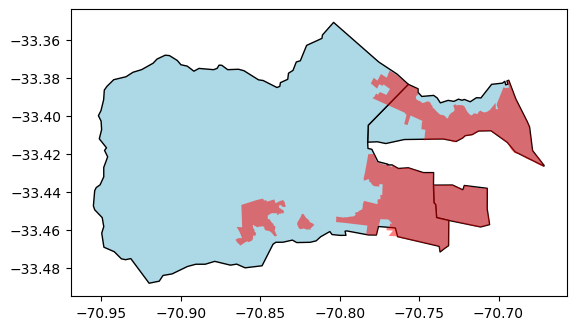

In [58]:
ax = comunas[comunas['nom_com'].isin(['PUDAHUEL', 'RENCA','LO PRADO'])].plot(color='lightblue', edgecolor='black')
areas_pob[areas_pob['nom_com'].isin(['PUDAHUEL', 'RENCA','LO PRADO'])].plot(ax=ax, color='red', alpha=0.5)

plt.show()

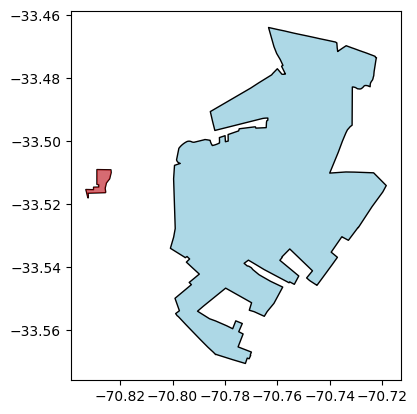

In [63]:
# ax = comunas[comunas['nom_com'].isin(['MAIPÚ', 'CERRILLOS','ESTACIÓN CENTRAL'])].plot(color='lightblue', edgecolor='black')
# areas_pob[areas_pob['nom_com'].isin(['MAIPÚ', 'CERRILLOS','ESTACIÓN CENTRAL'])].plot(ax=ax, color='red', alpha=0.5)

# ax = areas_pob[areas_pob['nom_com'].isin(['MAIPÚ', 'CERRILLOS','ESTACIÓN CENTRAL'])].plot(color='lightblue', edgecolor='black')
# comunas[comunas['nom_com'].isin(['MAIPÚ', 'CERRILLOS','ESTACIÓN CENTRAL'])].plot(ax=ax, color='red', alpha=0.5)

# plt.show()

ax = areas_pob[areas_pob['nom_com'].isin(['MAIPÚ'])].plot(color='lightblue', edgecolor='black')
comunas[comunas['nom_com'].isin(['MAIPÚ'])].plot(ax=ax, color='red', alpha=0.5)

plt.show()

<Axes: >

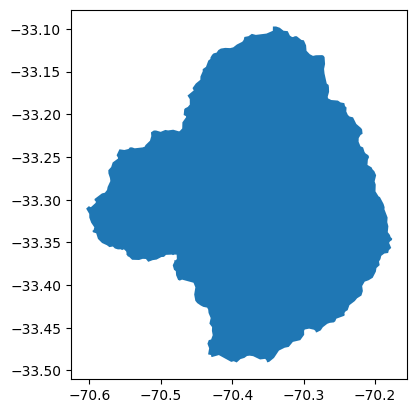

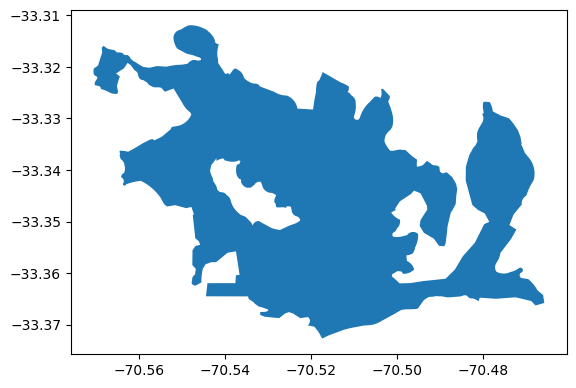

In [51]:
comunas[comunas['nom_com'].isin(['LO BARNECHEA'])].plot()
areas_pob[areas_pob['nom_com'].isin(['LO BARNECHEA'])].plot()

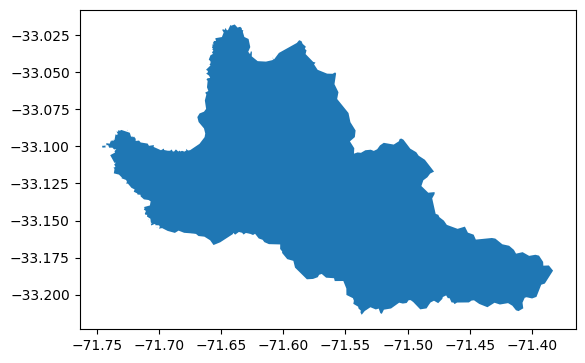

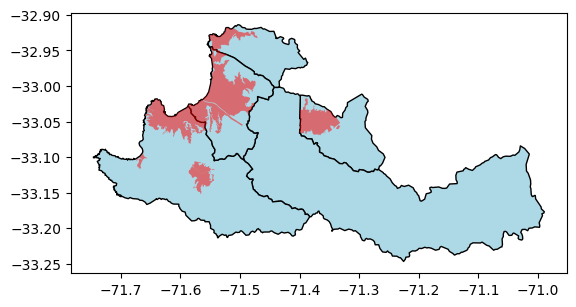

['VIÑA DEL MAR', 'VALPARAÍSO', 'QUILPUÉ', 'VILLA ALEMANA', 'CONCÓN']


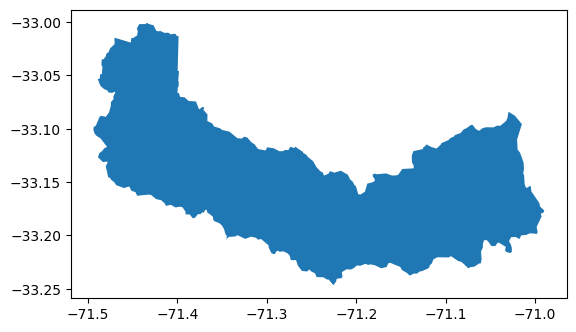

In [31]:
from shapely.geometry import box

# Crear bounding box de Chile continental
bbox = box(-75, -56, -66, -17)  # [min_lon, min_lat, max_lon, max_lat]
mask = comunas['nom_com'] == 'VALPARAÍSO'
comunas.loc[mask, 'geometry'] = comunas.loc[mask, 'geometry'].intersection(bbox)

# Plot para verificar
comunas[comunas['nom_com'] == 'VALPARAÍSO'].plot()

plt.show()

ax = comunas[comunas['nom_com'].isin(VALPO)].plot(color='lightblue', edgecolor='black')
areas_pob[areas_pob['nom_com'].isin(VALPO)].plot(ax=ax, color='red', alpha=0.5)

plt.show()


comunas[comunas['nom_com']=='QUILPUÉ'].plot()

print(VALPO)

In [14]:
# Reemplazar polígono de comunas extensas no pobladas (ej las coordilleranas) por el de Areas Pobladas
com_ext = ['LO BARNECHEA', 'LAS CONDES','LA FLORIDA', 'LA REINA','PUENTE ALTO', 'PEÑALOLÉN','MAIPÚ',
           #'PUDAHUEL','SAN BERNARDO'
           ]

for comuna in com_ext:
    # Encontrar la geometría de areas_pob para esta comuna
    nueva_geom = areas_pob[areas_pob['nom_com'] == comuna].geometry.iloc[0]
    
    # Reemplazar en comunas
    comunas.loc[comunas['nom_com'] == comuna, 'geometry'] = nueva_geom

In [16]:
years_map = [2002,
             2017, 2020
             ]

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=[f'{year}' for year in years_map],
    specs=[[{"type": "choropleth"} for _ in years_map]]
)

for i, year in enumerate(years_map, 1):
    df_year = df_stgo[df_stgo['Years'] == year]
    df_year['cod_com'] = df_year['cod_com'].astype(str)
    df_year = df_year.merge(comunas[['cod_com', 'geometry']], on='cod_com', how='left')
    gdf_year = gpd.GeoDataFrame(df_year, geometry='geometry')
    # Crear choropleth manualmente
    choropleth = go.Choropleth(
        geojson=gdf_year.geometry.__geo_interface__,
        locations=gdf_year.index,
        #z=gdf_year['DrinkingWater'],
        z=gdf_year['DWpp'],
        text=gdf_year['nom_com'],
        hoverinfo='text+z',
        colorscale='Blues',
        colorbar=dict(
            title="Drinking Water",
            len=0.8,
            y=0.5,
            yanchor="middle"
        ) if i == 3 else None,  # Solo mostrar colorbar en el último
        showscale=(i == 3)  # Solo mostrar scale en el último
    )
    
    fig.add_trace(choropleth, row=1, col=i)
    fig.update_geos(fitbounds="locations", visible=False, row=1, col=i)

fig.update_layout(
    height=500,
    width=1200,
    #margin={"r":0,"t":0,"l":0,"b":0},
)


gdf_2020 = gdf_year[gdf_year['Years'] == 2020]
  
fig2 = px.choropleth(gdf_2020,
                    geojson=gdf_2020.geometry,
                    locations=gdf_2020.index,
                    hover_data=['nom_com'],
                    color="DrinkingWater",
                    #color="DWpp",
                    color_continuous_scale="Blues",
                    projection="mercator")
fig2.update_traces(marker_line_width=0.3, marker_line_color='gray')     
fig2.update_geos(fitbounds="locations", visible=False)
fig2.update_layout(margin={"r":0,"t":0,"l":0,"b":0})

# Función para determinar si el color es oscuro o claro
def get_text_color(value, min_val, max_val):
    # Normalizar el valor entre 0 y 1
    normalized = (value - min_val) / (max_val - min_val)
    # Los valores más altos (colores más oscuros en Blues) necesitan texto blanco
    # Ajustar el threshold según lo que funcione mejor
    if normalized > 0.6: 
        return 'white'
    else:
        return 'black'

# Obtener min y max del valor que determina el color
min_val = gdf_2020['DrinkingWater'].min()
max_val = gdf_2020['DrinkingWater'].max()
#min_val = gdf_2020['DWpp'].min()
#max_val = gdf_2020['DWpp'].max()

gdf_2020['geometry'] = gdf_2020['geometry'].buffer(0) # reparar geometrías


divisiones_especificas = {
    'SAN JOAQUÍN': ('SAN<br>JOAQUÍN<br>', 9),
    'ESTACIÓN CENTRAL': ('ESTACIÓN<br>CENTRAL', 9),
    'SAN MIGUEL': ('<br><br>SAN<br>MIGUEL', 9),
    'QUINTA NORMAL': ('QUINTA<br>NORMAL', 10),
    'PEDRO AGUIRRE CERDA': ('PEDRO<br>AGUIRRE<br>CERDA', 9),
    'CERRO NAVIA': ('CERRO<br>NAVIA', 10),
    'PUENTE ALTO': ('PUENTE<br>ALTO', 10),
    'LO ESPEJO': ('LO<br>ESPEJO', 9),
    'LA CISTERNA': ('LA<br>CISTERNA', 9),
    'SAN RAMÓN': ('<br><br>SAN<br>RAMÓN', 9),
    'LA GRANJA': ('LA<br>GRANJA<br><br>', 9),
    'LO PRADO':('LO<br>PRADO',10),
    'CERRILLOS':('<br>CERRILLOS  ',9),
    'INDEPENDENCIA':('INDEPEN-<br>DENCIA',9),
    'PROVIDENCIA':('PROVIDENCIA',9),
    'MACUL':('MACUL<br>',10),
    'PEÑALOLÉN':('PEÑALOLÉN<br>',11),
    'SANTIAGO':('  SANTIAGO',10),
    'RECOLETA':('RECOLETA<br>',10),
    'CONCHALÍ':('CONCHALÍ<br>',10)
}

for idx, row in gdf_2020.iterrows():
    centroid = row.geometry.centroid
    text_color = get_text_color(row['DrinkingWater'], min_val, max_val)
    #text_color = get_text_color(row['DWpp'], min_val, max_val)
    nombre_comuna = row['nom_com'].upper()
    if nombre_comuna in divisiones_especificas:
        texto, tamano = divisiones_especificas[nombre_comuna]
    else:
        texto, tamano = row['nom_com'], 11
    
    fig2.add_trace(go.Scattergeo(
        lon=[centroid.x],
        lat=[centroid.y],
        text=texto,
        mode='text',
        textfont=dict(
            #size=10,
            size=tamano,
            color=text_color,
            family='Arial'
        ),
        showlegend=False,
        hoverinfo='skip'
    ))



fig2.update_geos(fitbounds="locations", visible=False)
fig2.update_layout(coloraxis_colorbar_title_text="DW")
#fig2.update_layout(coloraxis_colorbar_title_text="DWpp")
fig2.show()


In [235]:
fig2.write_image("stgo_2020_dw.pdf", format="pdf", width=1800, height=1200)
fig2.write_image("stgo_2020_dw.svg", format="svg", width=1800, height=1200)
fig2.write_image("stgo_2020_dw.png", format="png", width=1800, height=1200)

In [17]:
gdf_2020['cod_com'] = gdf_2020['cod_com'].astype(int)
gdf_2020 = gdf_2020.merge(df_model2[['cod_com', 'ISMT']], on='cod_com', how='left')

In [31]:
fig3 = px.choropleth(gdf_2020,
                    geojson=gdf_2020.geometry,
                    locations=gdf_2020.index,
                    hover_data=['nom_com'],
                    color="ISMT",
                    #color="DWpp",
                    color_continuous_scale="SunsetDark",
                    projection="mercator")
fig3.update_traces(marker_line_width=0.3, marker_line_color='gray')     
fig3.update_geos(fitbounds="locations", visible=False)
fig3.update_layout(margin={"r":0,"t":0,"l":0,"b":0})

# Obtener min y max del valor que determina el color
min_val = gdf_2020['ISMT'].min()
max_val = gdf_2020['ISMT'].max()

gdf_2020['geometry'] = gdf_2020['geometry'].buffer(0) # reparar geometrías


for idx, row in gdf_2020.iterrows():
    centroid = row.geometry.centroid
    text_color = get_text_color(row['ISMT'], min_val, max_val)
    nombre_comuna = row['nom_com'].upper()
    if nombre_comuna in divisiones_especificas:
        texto, tamano = divisiones_especificas[nombre_comuna]
    else:
        texto, tamano = row['nom_com'], 11
    
    fig3.add_trace(go.Scattergeo(
        lon=[centroid.x],
        lat=[centroid.y],
        text=texto,
        mode='text',
        textfont=dict(
            #size=10,
            size=tamano,
            color=text_color,
            family='Arial'
        ),
        showlegend=False,
        hoverinfo='skip'
    ))


fig3.update_geos(fitbounds="locations", visible=False)
fig3.update_layout(coloraxis_colorbar_title_text="ISMT")
#fig2.update_layout(coloraxis_colorbar_title_text="DWpp")
fig3.show()


In [77]:
fig3.write_image("stgo_2020_ISMT.pdf", format="pdf", width=1800, height=1200)
fig3.write_image("stgo_2020_ISMT.svg", format="svg", width=1800, height=1200)
fig3.write_image("stgo_2020_ISMT.png", format="png", width=1800, height=1200)

In [44]:
# VIÑA

df_valpo2020 = df_valpo[df_valpo['Years'] == 2020]
df_valpo2020['cod_com'] = df_valpo2020['cod_com'].astype(str)
df_valpo2020 = df_valpo2020.merge(comunas[['cod_com','geometry']],on='cod_com')
gdf_valpo2020 = gpd.GeoDataFrame(df_valpo2020,geometry='geometry')

gdf_valpo2020['cod_com'] = gdf_valpo2020['cod_com'].astype(int)
gdf_valpo2020 = gdf_valpo2020.merge(df_model2[['cod_com', 'ISMT']], on='cod_com', how='left')

fig4 = px.choropleth(gdf_valpo2020,
                    geojson=gdf_valpo2020.geometry,
                    locations=gdf_valpo2020.index,
                    #locations = 'cod_com',
                    hover_data=['nom_com'],
                    #color="DrinkingWater",
                    #color="DWpp",
                    color="ISMT",
                    #color_continuous_scale="Blues",
                    color_continuous_scale="SunsetDark",
                    projection="mercator")
fig4.update_traces(marker_line_width=0.3, marker_line_color='gray')     
fig4.update_geos(fitbounds="locations",
                 center=dict(lat=-32.5, lon=-71),
                 lataxis_range=[-33, -32.5],
                 lonaxis_range=[-72, -70],
                 visible=False 
                 #visible=True,
                 #lataxis_showgrid=True, lonaxis_showgrid=True
                 )
# min_val = gdf_valpo2020['DrinkingWater'].min()
# max_val = gdf_valpo2020['DrinkingWater'].max()
# min_val = gdf_valpo2020['DWpp'].min()
# max_val = gdf_valpo2020['DWpp'].max()
min_val = gdf_valpo2020['ISMT'].min()
max_val = gdf_valpo2020['ISMT'].max()

for idx, row in gdf_valpo2020.iterrows():
    centroid = row.geometry.centroid
    #text_color = get_text_color(row['DrinkingWater'], min_val, max_val)
    #text_color = get_text_color(row['DWpp'], min_val, max_val)
    text_color = get_text_color(row['ISMT'], min_val, max_val)
    nombre_comuna = row['nom_com'].upper()
    texto, tamano = row['nom_com'], 11

    fig4.add_trace(go.Scattergeo(
        lon=[centroid.x],
        lat=[centroid.y],
        text=texto,
        mode='text',
        textfont=dict(
            size=10,
            #size=tamano,
            color=text_color,
            family='Arial'
        ),
        showlegend=False,
        hoverinfo='skip'
    ))

fig4.update_layout(margin={"r":0,"t":0,"l":0,"b":0},
                       #geo=dict(lataxis_range=[-33, -32.5],lonaxis_range=[-71.9, -71],
                           #showland=True,
                           #landcolor="lightgray"
                        #   )

                   )

fig4.show()

/var/folders/dp/hq1q_fc122s8pmzf1bjlmq000000gn/T/ipykernel_2280/3087729500.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [45]:
fig4.write_image("valpo_2020_ISMT.pdf", format="pdf", width=1800, height=1200)
fig4.write_image("valpo_2020_ISMT.svg", format="svg", width=1800, height=1200)
fig4.write_image("valpo_2020_ISMT.png", format="png", width=1800, height=1200)

In [53]:
# 🧠 Tu situación:

#     ✅ El test Breusch-Pagan dio significativo → hay heterocedasticidad.

#     ✅ Visualmente no hay patrón fuerte → no parece grave o estructural.

#     ❗ Tienes pocos datos.

#     ❌ No conoces la forma funcional de la varianza → difícil usar WLS o GLS bien.

#     ✔️ Quieres que los coeficientes sean interpretables y comparables.

#     ✔️ No necesitas cambiar la forma del modelo.

In [57]:
# ¿No tener distribución normal de residuos = no cumplir homocedasticidad?

# No necesariamente, son supuestos distintos:

#     📊 Normalidad de residuos: los errores (residuos) deben seguir una distribución normal. Importa sobre todo para realizar inferencia estadística confiable (p-values, intervalos de confianza).

#     📈 Homoscedasticidad: los residuos deben tener varianza constante en todos los niveles de la variable independiente. Esto es fundamental para que los estimadores OLS sean eficientes.

# 👉 Puedes tener residuos no normales pero homocedásticos, o viceversa.


# La normalidad de los residuos es importante si vas a hacer inferencia: obtener p-valores, construir intervalos de confianza o hacer predicciones con intervalos.

# No es requisito para que los coeficientes del modelo estén bien estimados. Si el objetivo es explicar la relación entre variables, la violación de normalidad no invalida el modelo